In [246]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import dill
import json
import sys
import os
from scipy import spatial
import matplotlib.pyplot as plt

In [247]:
dict_path = 'data/reshaped_ev_points.csv'
ev_points = pd.read_csv(dict_path)
cluster = np.unique(ev_points['cluster'].values)

In [248]:
rand_clusters = cluster
#rand_clusters = [71,80,106]
clusters_df = ev_points[ev_points['cluster'].isin(rand_clusters)]
ev_points_n_clusters = clusters_df[['ev_points_id', 'x', 'y', 'z']].values
#ev_points_n_clusters = ev_points[['ev_points_id', 'x', 'y', 'z']].values


In [249]:
t = 1870
threshold = 60

In [250]:
result_path = 'results/NO_concentration_data_CS_5ms_cycled_2/'
concentration_CS_clusters = []
for i in range(0,t,5):
    file_path = result_path + f'NO_concentration_t_{i}.csv'
    df_conc = pd.read_csv(file_path,header=None)
    matched_conc = df_conc[df_conc.iloc[:,1].isin(ev_points_n_clusters[:, 0])]
    concentrations = matched_conc.iloc[:, 2].values
    #concentrations[concentrations<160] = 0
    #log_concentrations = np.log10(concentrations + epsilon)
    concentration_CS_clusters.append(concentrations)

In [251]:
concentration_CS_clusters = np.array(concentration_CS_clusters)
max_value_index = np.argmax(concentration_CS_clusters)

# Get the row and column index of the max value
row, col = np.unravel_index(max_value_index, concentration_CS_clusters.shape)
concentration_plot_CS = concentration_CS_clusters[:,col]
concentration_CS_clusters[row,col]

np.float64(244.318538611246)

In [252]:
result_path = 'results/NO_concentration_data_noise_5ms_cycled_2/'
concentration_noise_clusters = []
for i in range(0,t,5):
    file_path = result_path + f'NO_concentration_t_{i}.csv'
    df_conc = pd.read_csv(file_path,header=None)
    matched_conc = df_conc[df_conc.iloc[:, 1].isin(ev_points_n_clusters[:, 0])]
    concentrations = matched_conc.iloc[:, 2].values
    #concentrations[concentrations<160] = 0
    #log_concentrations = np.log10(concentrations + epsilon)
    concentration_noise_clusters.append(concentrations)

In [253]:
concentration_noise_clusters = np.array(concentration_noise_clusters)
max_value_index = np.argmax(concentration_noise_clusters)

# Get the row and column index of the max value
row, col = np.unravel_index(max_value_index, concentration_noise_clusters.shape)
concentration_plot_noise = concentration_noise_clusters[:,col]
concentration_noise_clusters[row,col]

np.float64(142.6656513584274)

In [254]:
CS_above_threshold = [np.sum(conc > threshold) for conc in concentration_CS_clusters]
noise_above_threshold = [np.sum(conc > threshold) for conc in concentration_noise_clusters]
CS_proportion = [np.mean(conc > threshold) for conc in concentration_CS_clusters]
noise_proportion = [np.mean(conc > threshold) for conc in concentration_noise_clusters]

In [255]:
normal_summary = {
    'mean': np.mean(CS_above_threshold),
    'std_dev': np.std(CS_above_threshold)
}
noise_summary = {
    'mean': np.mean(noise_above_threshold),
    'std_dev': np.std(noise_above_threshold)
}

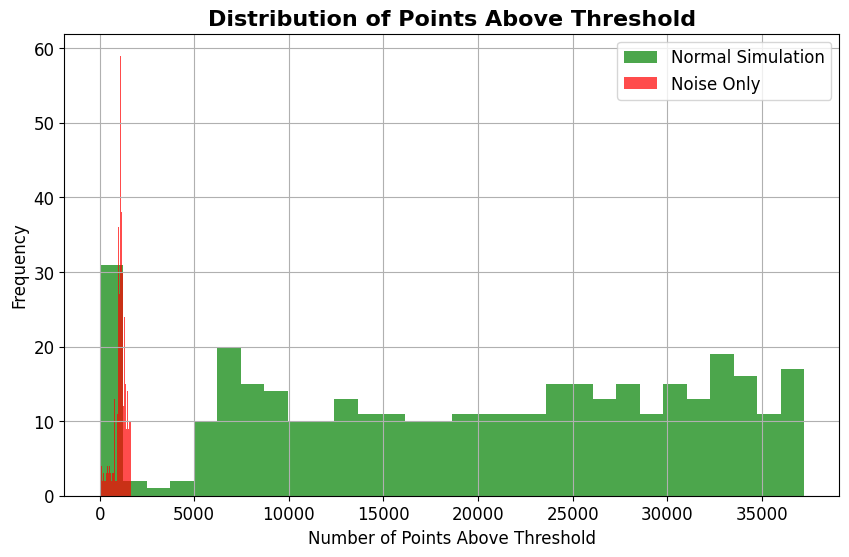

In [256]:
plt.rcParams.update({'font.size': 12},)
plt.figure(figsize=(10, 6))
plt.hist(CS_above_threshold, bins=30, alpha=0.7, label='Normal Simulation', color='g')
plt.hist(noise_above_threshold, bins=30, alpha=0.7, label='Noise Only', color='r')
#plt.axvline(x=threshold, color='red', linestyle='--', label='Threshold (130 pM)')
plt.xlabel('Number of Points Above Threshold')
plt.ylabel('Frequency')
plt.title('Distribution of Points Above Threshold', fontsize=16,fontweight ='bold')
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_2656727/3264598235.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([CS_above_threshold, noise_above_threshold], labels=['Normal', 'Noise Only'])


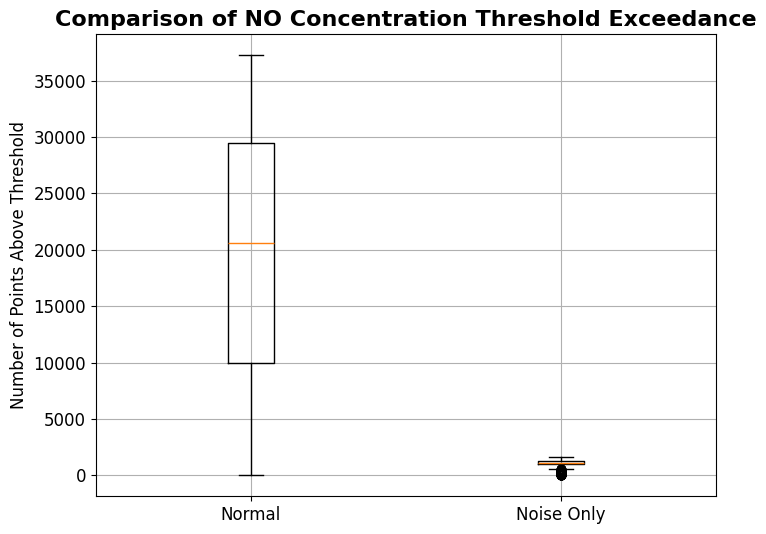

In [257]:
plt.figure(figsize=(8, 6))
plt.boxplot([CS_above_threshold, noise_above_threshold], labels=['Normal', 'Noise Only'])
plt.ylabel('Number of Points Above Threshold')
plt.title('Comparison of NO Concentration Threshold Exceedance', fontsize=16,fontweight ='bold')
plt.grid(True)
plt.show()

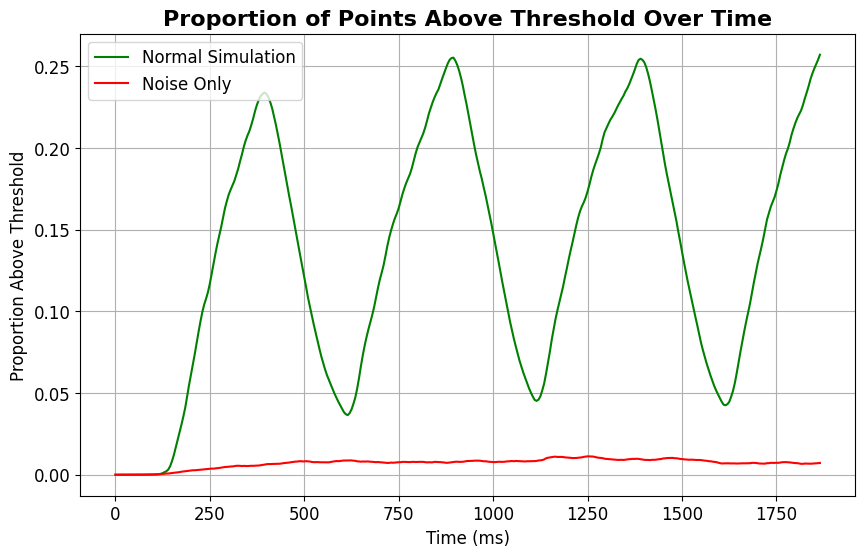

In [258]:
plt.rcParams.update({'font.size': 12},)
time = np.arange(0, t, 5) 
plt.figure(figsize=(10, 6))
plt.plot(time, CS_proportion, label='Normal Simulation', color='g')
plt.plot(time, noise_proportion, label='Noise Only', color='r')
#plt.axhline(y=0.5, color='red', linestyle='--', label='50% Proportion')
plt.xlabel('Time (ms)')
plt.ylabel('Proportion Above Threshold')
plt.title('Proportion of Points Above Threshold Over Time', fontsize=16,fontweight ='bold')
plt.legend()
plt.grid(True)
plt.show()

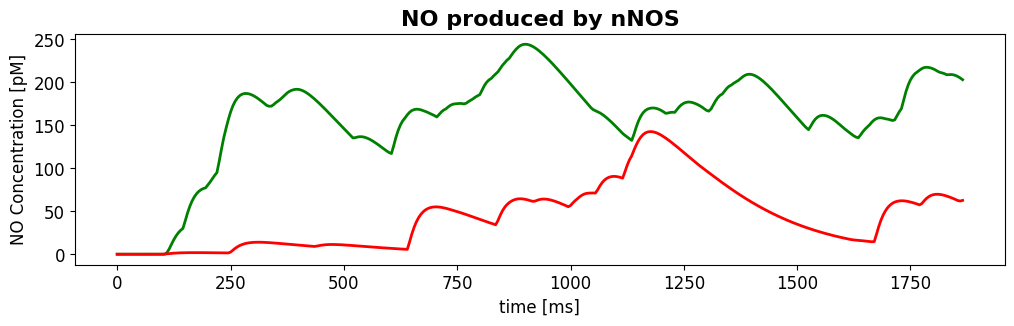

In [259]:
#plt.rcParams.update({'font.size': 12},)
plt.figure(figsize=(12,3))
plt.plot(np.arange(0,t,5),concentration_plot_CS, 'g', linewidth=2)
plt.plot(np.arange(0,t,5),concentration_plot_noise, 'r', linewidth=2)
plt.xlabel('time [ms]')
plt.ylabel('NO Concentration [pM]')
#plt.grid(visible=True)
plt.title('NO produced by nNOS', fontsize=16,fontweight ='bold')
#plt.savefig('vm_neuron.png')
plt.show()

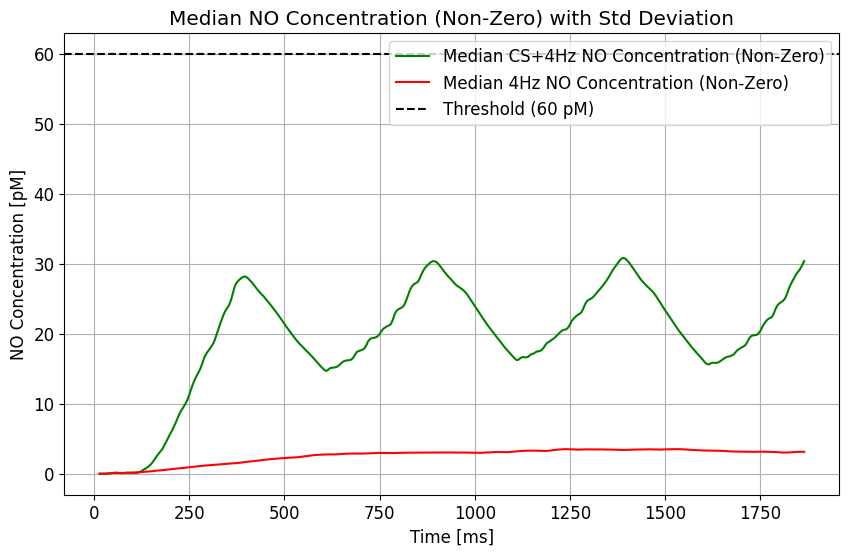

In [260]:
# Initialize lists for storing results
CS_filtered_median = []
CS_filtered_std = []
CS_filtered_time = []
noise_filtered_median = []
noise_filtered_std = []
noise_filtered_time = []

# Loop through each time point and compute stats
for i in range(concentration_CS_clusters.shape[0]):
    non_zero_values = concentration_CS_clusters[i][concentration_CS_clusters[i] > 0]  # Filter out zeros
    if len(non_zero_values) > 0:  # Only process if there are non-zero values
        CS_filtered_median.append(np.median(non_zero_values))  # Median of non-zero values
        CS_filtered_std.append(np.std(non_zero_values))        # Std of non-zero values
        CS_filtered_time.append(time[i])                      # Save corresponding time
    non_zero_values = concentration_noise_clusters[i][concentration_noise_clusters[i] > 0]  # Filter out zeros
    if len(non_zero_values) > 0:  # Only process if there are non-zero values
        noise_filtered_median.append(np.median(non_zero_values))  # Median of non-zero values
        noise_filtered_std.append(np.std(non_zero_values))        # Std of non-zero values
        noise_filtered_time.append(time[i])
# Convert lists to numpy arrays for plotting
CS_filtered_median = np.array(CS_filtered_median)
CS_filtered_std = np.array(CS_filtered_std)
CS_filtered_time = np.array(CS_filtered_time)

noise_filtered_median = np.array(noise_filtered_median)
noise_filtered_std = np.array(noise_filtered_std)
noise_filtered_time = np.array(noise_filtered_time)

step_size = 100 // 5  # Convert 50 ms to the number of steps
CS_downsampled_times = CS_filtered_time[::step_size]
CS_downsampled_std = CS_filtered_std[::step_size]

noise_downsampled_times = noise_filtered_time[::step_size]
noise_downsampled_std = noise_filtered_std[::step_size]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(CS_filtered_time, CS_filtered_median, label='Median CS+4Hz NO Concentration (Non-Zero)', color='green')
plt.plot(noise_filtered_time, noise_filtered_median, label='Median 4Hz NO Concentration (Non-Zero)', color='red')
plt.axhline(y=threshold, color='black', linestyle='--', label=f'Threshold ({threshold} pM)')

plt.xlabel('Time [ms]')
plt.ylabel('NO Concentration [pM]')
plt.title('Median NO Concentration (Non-Zero) with Std Deviation')
plt.legend()
plt.grid(True)
plt.show()

In [261]:
result_path = 'results/NO_concentration_data_CS_5ms_cycled_1/'
concentration_CS_clusters = []
for i in range(0,t,5):
    file_path = result_path + f'NO_concentration_t_{i}.csv'
    df_conc = pd.read_csv(file_path, header = None)
    matched_conc = df_conc[df_conc.iloc[:, 1].isin(ev_points_n_clusters[:, 0])]
    concentrations = matched_conc.iloc[:, 2].values
    #concentrations[concentrations<160] = 0
    #log_concentrations = np.log10(concentrations + epsilon)
    concentration_CS_clusters.append(concentrations)

In [262]:
concentration_CS_clusters = np.array(concentration_CS_clusters)
max_value_index = np.argmax(concentration_CS_clusters)

# Get the row and column index of the max value
row, col = np.unravel_index(max_value_index, concentration_CS_clusters.shape)
concentration_plot_CS = concentration_CS_clusters[:,col]
concentration_CS_clusters[row,col]

np.float64(411.5209079040204)

In [263]:
result_path = 'results/NO_concentration_data_noise_5ms_cycled_1/'
concentration_noise_clusters = []
for i in range(0,t,5):
    file_path = result_path + f'NO_concentration_t_{i}.csv'
    df_conc = pd.read_csv(file_path, header = None)
    matched_conc = df_conc[df_conc.iloc[:, 1].isin(ev_points_n_clusters[:, 0])]
    concentrations = matched_conc.iloc[:, 2].values
    #concentrations[concentrations<160] = 0
    #log_concentrations = np.log10(concentrations + epsilon)
    concentration_noise_clusters.append(concentrations)

In [264]:
concentration_noise_clusters = np.array(concentration_noise_clusters)
max_value_index = np.argmax(concentration_noise_clusters)

# Get the row and column index of the max value
row, col = np.unravel_index(max_value_index, concentration_noise_clusters.shape)
concentration_plot_noise = concentration_noise_clusters[:,col]
concentration_noise_clusters[row,col]

np.float64(216.6092116221987)

In [265]:
CS_above_threshold = [np.sum(conc > threshold) for conc in concentration_CS_clusters]
noise_above_threshold = [np.sum(conc > threshold) for conc in concentration_noise_clusters]
CS_proportion = [np.mean(conc > threshold) for conc in concentration_CS_clusters]
noise_proportion = [np.mean(conc > threshold) for conc in concentration_noise_clusters]
normal_summary = {
    'mean': np.mean(CS_above_threshold),
    'std_dev': np.std(CS_above_threshold)
}
noise_summary = {
    'mean': np.mean(noise_above_threshold),
    'std_dev': np.std(noise_above_threshold)
}


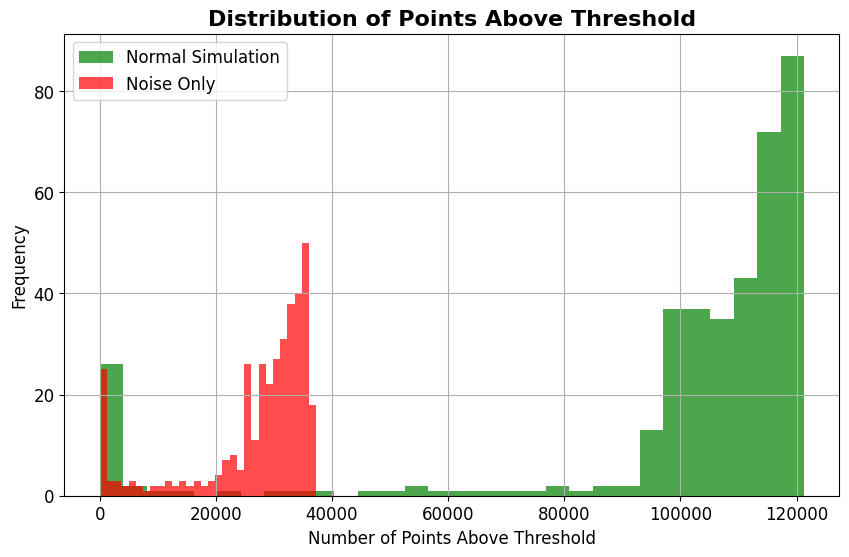

In [266]:
plt.figure(figsize=(10, 6))
plt.hist(CS_above_threshold, bins=30, alpha=0.7, label='Normal Simulation', color='g')
plt.hist(noise_above_threshold, bins=30, alpha=0.7, label='Noise Only', color='r')
#plt.axvline(x=threshold, color='red', linestyle='--', label='Threshold (130 pM)')
plt.xlabel('Number of Points Above Threshold')
plt.ylabel('Frequency')
plt.title('Distribution of Points Above Threshold', fontsize=16,fontweight ='bold')
plt.legend()
plt.grid(True)
plt.show()


/tmp/ipykernel_2656727/1677297546.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([CS_above_threshold, noise_above_threshold], labels=['Normal', 'Noise Only'])


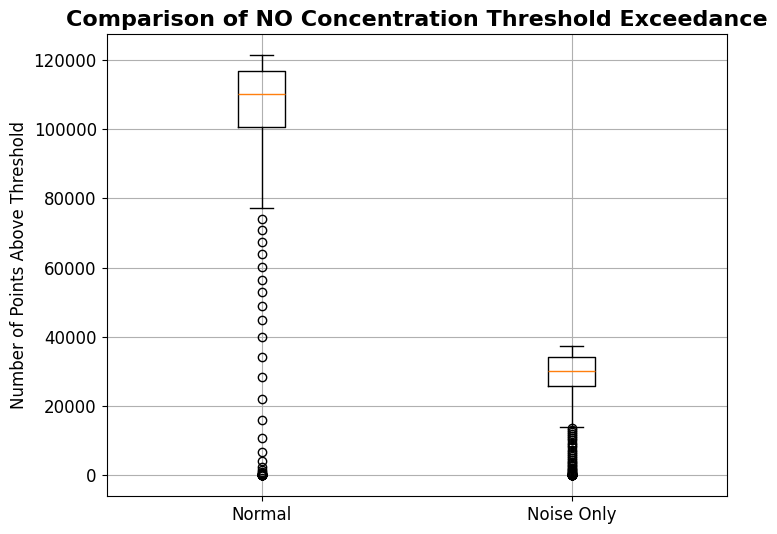

In [267]:

plt.figure(figsize=(8, 6))
plt.boxplot([CS_above_threshold, noise_above_threshold], labels=['Normal', 'Noise Only'])
plt.ylabel('Number of Points Above Threshold')
plt.title('Comparison of NO Concentration Threshold Exceedance', fontsize=16,fontweight ='bold')
plt.grid(True)
plt.show()


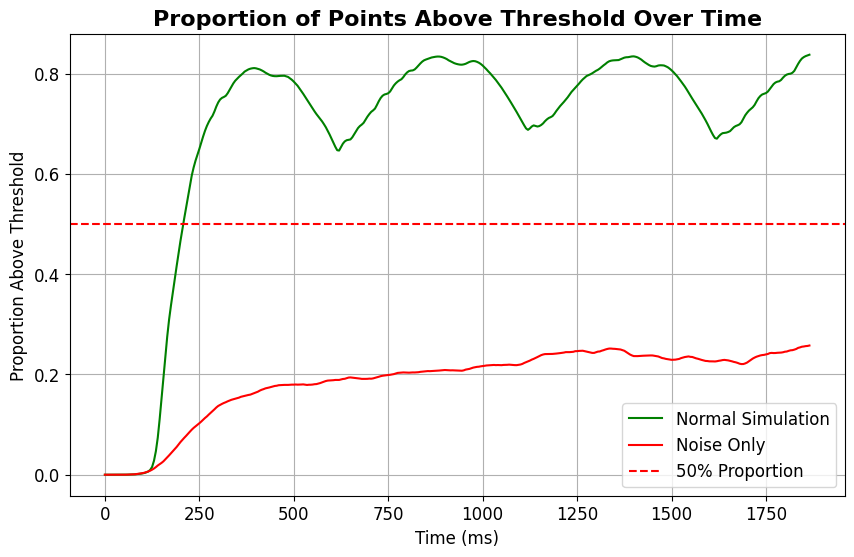

In [ ]:

time = np.arange(0, t, 5) 
plt.figure(figsize=(10, 6))
plt.plot(time, CS_proportion, label='Normal Simulation', color='g')
plt.plot(time, noise_proportion, label='Noise Only', color='r')
#plt.axhline(y=0.5, color='red', linestyle='--', label='50% Proportion')
plt.xlabel('Time (ms)')
plt.ylabel('Proportion Above Threshold')
plt.title('Proportion of Points Above Threshold Over Time', fontsize=16,fontweight ='bold')
plt.legend()
plt.grid(True)
plt.show()

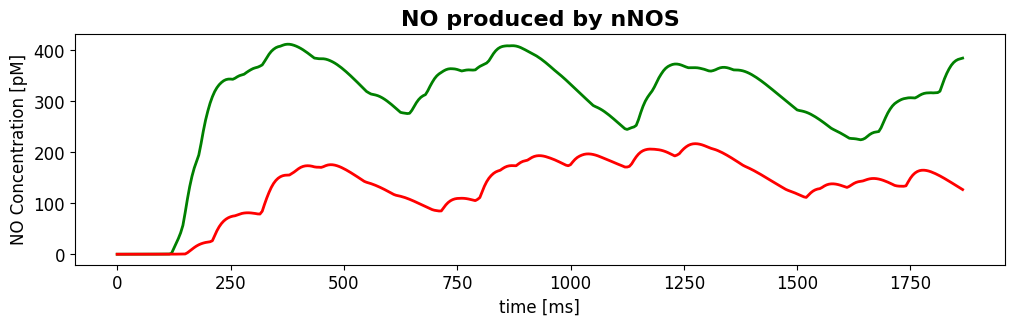

In [269]:
plt.rcParams.update({'font.size': 12},)
plt.figure(figsize=(12,3))
plt.plot(np.arange(0,t,5),concentration_plot_CS, 'g', linewidth=2)
plt.plot(np.arange(0,t,5),concentration_plot_noise, 'r', linewidth=2)
plt.xlabel('time [ms]')
plt.ylabel('NO Concentration [pM]')
#plt.grid(visible=True)
plt.title('NO produced by nNOS', fontsize=16,fontweight ='bold')
#plt.savefig('vm_neuron.png')
plt.show()

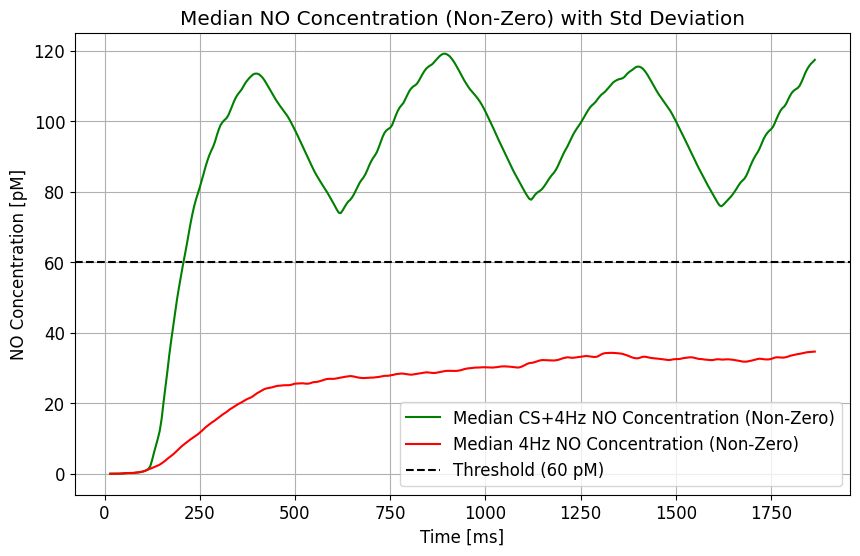

In [270]:
# Initialize lists for storing results
CS_filtered_median = []
CS_filtered_std = []
CS_filtered_time = []
noise_filtered_median = []
noise_filtered_std = []
noise_filtered_time = []

# Loop through each time point and compute stats
for i in range(concentration_CS_clusters.shape[0]):
    non_zero_values = concentration_CS_clusters[i][concentration_CS_clusters[i] > 0]  # Filter out zeros
    if len(non_zero_values) > 0:  # Only process if there are non-zero values
        CS_filtered_median.append(np.median(non_zero_values))  # Median of non-zero values
        CS_filtered_std.append(np.std(non_zero_values))        # Std of non-zero values
        CS_filtered_time.append(time[i])                      # Save corresponding time
    non_zero_values = concentration_noise_clusters[i][concentration_noise_clusters[i] > 0]  # Filter out zeros
    if len(non_zero_values) > 0:  # Only process if there are non-zero values
        noise_filtered_median.append(np.median(non_zero_values))  # Median of non-zero values
        noise_filtered_std.append(np.std(non_zero_values))        # Std of non-zero values
        noise_filtered_time.append(time[i])
# Convert lists to numpy arrays for plotting
CS_filtered_median = np.array(CS_filtered_median)
CS_filtered_std = np.array(CS_filtered_std)
CS_filtered_time = np.array(CS_filtered_time)

noise_filtered_median = np.array(noise_filtered_median)
noise_filtered_std = np.array(noise_filtered_std)
noise_filtered_time = np.array(noise_filtered_time)

step_size = 100 // 5  # Convert 50 ms to the number of steps
CS_downsampled_times = CS_filtered_time[::step_size]
CS_downsampled_std = CS_filtered_std[::step_size]

noise_downsampled_times = noise_filtered_time[::step_size]
noise_downsampled_std = noise_filtered_std[::step_size]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(CS_filtered_time, CS_filtered_median, label='Median CS+4Hz NO Concentration (Non-Zero)', color='green')
plt.plot(noise_filtered_time, noise_filtered_median, label='Median 4Hz NO Concentration (Non-Zero)', color='red')
plt.axhline(y=threshold, color='black', linestyle='--', label=f'Threshold ({threshold} pM)')

# Add labels and legend
plt.xlabel('Time [ms]')
plt.ylabel('NO Concentration [pM]')
plt.title('Median NO Concentration (Non-Zero) with Std Deviation')
plt.legend()
plt.grid(True)
plt.show()